# Hits prediction using MMELON and MAMMAL models

## Overview

This notebook provides a unified workflow to apply inference of  **MMELON** and **MAMMAL** models for hit predictions on two datasets:

- **PGK2 DEL**: PGK2 DEL prediction task
- **WDR91 ASMS**: WDR91 ASMS prediction task

### Models:

1. **MMELON (Multi-view Molecular Embedding with Late Fusion)**
   - Paper: https://advanced.onlinelibrary.wiley.com/doi/10.1002/advs.202517840
   - GitHub: https://github.com/BiomedSciAI/biomed-multi-view
   
2. **MAMMAL (Molecular Aligned Multi-Modal Architecture and Language)**
   - Paper: (https://arxiv.org/abs/2410.22367v2)
   - GitHub: https://github.com/BiomedSciAI/biomed-multi-alignment/

### Features:

- Run predictions for both PGK2 and WDR91 datasets
- Compare MMELON and MAMMAL model performance
- Calculate comprehensive metrics (ROC-AUC, PR-AUC, Enrichment@K)
- Molecular clustering and diversity analysis
- Batch processing for efficient inference

### Workflow:

1. **Setup**: Install dependencies and configure datasets
2. **Data Exploration**: Analyze input data with clustering
3. **Model Predictions**: Run MMELON and MAMMAL predictions
4. **Results Analysis**: Calculate metrics, enrichment, and visualize top hits

## Prerequisites

- Python >= 3.11
- Required libraries: `requests`, `pandas`, `scikit-learn`, `tqdm`, `rdkit`
- Valid API token from https://open.accelerate.science/portal/user

## 1. Configuration

Configure the datasets and models you want to run predictions on.

In [ ]:
def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False
IN_COLAB = in_colab()
print(f"{IN_COLAB=}")

IN_COLAB=False


In [ ]:
import os
# Dataset Configuration

if IN_COLAB:
    RESULTS_DIR = "/content/results"
    DATA_DIR = "/content/data"  
else:
    USER = os.getenv("USER")
    RESULTS_DIR = f"/proj/ligand_ai/users/{USER}/results"
    DATA_DIR = f"/proj/ligand_ai/users/{USER}/data"

DATASETS = {
    'pgk2': {
        'name': 'PGK2 DEL',
        'test_file': os.path.join(DATA_DIR, 'pgk2_del_test.csv'),
        'pred_file_pattern': os.path.join(RESULTS_DIR, 'pgk2_{model}_predictions.csv'),
        'label_column': 'label',
        'smiles_column': 'smiles',
        'max_samples': 200  # Set to a number (e.g., 1000) to run on a subset, or None for full dataset
    },
    'wdr91': {
        'name': 'WDR91 ASMS',
        'test_file': os.path.join(DATA_DIR, 'wdr91_asms_test.csv'),
        'pred_file_pattern': os.path.join(RESULTS_DIR, 'wdr91_{model}_predictions.csv'),
        'label_column': 'label',
        'smiles_column': 'smiles',
        'max_samples': None  # Set to a number (e.g., 1000) to run on a subset, or None for full dataset
    }
}


# Tasks to run (set to True to enable)
RUN_TASKS: dict[tuple[str, str], bool] = {
    ('mmelon', 'pgk2'): False,
    ('mmelon', 'wdr91'): True,
    ('mammal', 'pgk2'): False,
    ('mammal', 'wdr91'): True
}


print(f"{RESULTS_DIR=}")

RESULTS_DIR='/proj/ligand_ai/users/ozery/results'


## 2. Analysis methods

In [ ]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

In [ ]:
def cluster_molecules(smiles_list: list[str], cutoff: float = 0.35, fp_type: str = 'morgan2') -> list[tuple]:
    """
    Clusters SMILES strings with selectable fingerprint types using Butina algorithm.

    Args:
        smiles_list (list): List of SMILES strings.
        cutoff (float): Distance threshold (1 - similarity). Default is 0.35.
        fp_type (str): Fingerprint type. Options:
            - 'morgan2' or 'ecfp4': Morgan fingerprint with radius 2
            - 'morgan3' or 'ecfp6': Morgan fingerprint with radius 3
            - 'maccs': MACCS keys
            - 'rdkit': RDKit path-based fingerprint
            
    Returns:
        List of tuples, where each tuple contains indices of molecules in a cluster.
        The first element of each tuple is the cluster centroid.
        
    Example:
        >>> smiles = ['CCO', 'CCCO', 'CCCCO']
        >>> clusters = cluster_molecules(smiles, cutoff=0.35, fp_type='morgan2')
    """
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    valid_mols = [m for m in mols if m is not None]

    if len(valid_mols) < len(smiles_list):
        print(f"Warning: {len(smiles_list) - len(valid_mols)} invalid SMILES skipped.")

    # Generate the requested fingerprint type
    fps = []
    for m in valid_mols:
        if fp_type.lower() in ['morgan2', 'ecfp4']:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048))
        elif fp_type.lower() in ['morgan3', 'ecfp6']:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(m, 3, nBits=2048))
        elif fp_type.lower() == 'maccs':
            fps.append(MACCSkeys.GenMACCSKeys(m))
        elif fp_type.lower() == 'rdkit':
            fps.append(Chem.RDKFingerprint(m))
        else:
            raise ValueError("fp_type must be 'morgan2', 'ecfp4', 'morgan3', 'ecfp6', 'maccs', or 'rdkit'")

    # Generate distance matrix
    num_fps = len(fps)
    dist_matrix = []
    for i in range(1, num_fps):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dist_matrix.extend([1 - x for x in sims])

    # Cluster using Butina
    clusters = Butina.ClusterData(dist_matrix, num_fps, cutoff, isDistData=True)
    return clusters


In [ ]:
import pandas as pd
def interpret_clusters(clusters: list[tuple]) -> pd.DataFrame:
    """
    Convert cluster results into a DataFrame with cluster information.
    
    Args:
        clusters: Output from Butina clustering (list of tuples).
        
    Returns:
        DataFrame with columns:
            - ID: Original index of the molecule
            - CLUSTER_ID: Cluster identifier
            - CLUSTER_SIZE: Number of molecules in the cluster
            - CLUSTER_CENTROID: 1 if molecule is cluster centroid, 0 otherwise
            
    Example:
        >>> clusters = [(0, 1, 2), (3, 4)]
        >>> df = interpret_clusters(clusters)
    """
    clusters_df = pd.DataFrame()
    ele_list = []
    clusid_list = []
    clussize_list = []
    centroid_list = []
    
    for clusid, t in enumerate(clusters):
        clussize = len(t)
        for c, ele in enumerate(t):
            ele_list.append(ele)
            clusid_list.append(clusid)
            clussize_list.append(clussize)
            if c == 0:
                centroid_list.append(1)
            else:
                centroid_list.append(0)
                
    clusters_df["ID"] = ele_list
    clusters_df["CLUSTER_ID"] = clusid_list
    clusters_df["CLUSTER_SIZE"] = clussize_list
    clusters_df["CLUSTER_CENTROID"] = centroid_list
    return clusters_df.sort_values(by="ID").reset_index(drop=True)


In [ ]:
def plotmolblocks_n(
    smilist: list[str], 
    n: int = 20, 
    molsPerRow: int = 5, 
    labels: pd.DataFrame | None = None
) -> list:
    """
    Plot molecules in a grid with optional labels.
    
    Args:
        smilist: List of SMILES strings to visualize.
        n: Number of molecules to display. Default is 20.
        molsPerRow: Number of molecules per row in the grid. Default is 5.
        labels: DataFrame with label information to display under each molecule.
                Each row corresponds to a molecule, columns are label names.
        
    Returns:
        List containing the generated image(s).
        
    Example:
        >>> smiles = ['CCO', 'CCCO', 'CCCCO']
        >>> labels_df = pd.DataFrame({'ID': [0, 1, 2], 'Score': [0.9, 0.8, 0.7]})
        >>> imgs = plotmolblocks_n(smiles, labels=labels_df)
        >>> display(imgs[0])
    """
    mols = [Chem.MolFromSmiles(s) for s in smilist]
    valid_mols = [m for m in mols if m is not None]
    mollen = len(valid_mols)
    n_figs = mollen // n + 1
    imglist = []
    
    for i in range(1):
        molblock = valid_mols[i*n:min((i+1)*n, mollen)]
        legends = []
        
        if labels is not None:
            assert isinstance(labels, pd.DataFrame), "labels must be a pandas DataFrame"
            keys = labels.keys()
            for index, label in labels.iloc[i*n:min((i+1)*n, mollen)].iterrows():
                legend = ""
                for key in keys:
                    if isinstance(label[key], int):
                        legend = legend + f"{key}: {label[key]:d}\n"
                    elif isinstance(label[key], (float, np.float64)):
                        if label[key].is_integer():
                            legend = legend + f"{key}: {label[key]:.0f}\n"
                        else:
                            legend = legend + f"{key}: {label[key]:.6f}\n"
                    else:
                        legend = legend + f"{key}: {label[key]}\n"
                legends.append(legend)
                
        img = Draw.MolsToGridImage(
            molblock, 
            molsPerRow=molsPerRow, 
            subImgSize=(400, 400), 
            returnPNG=False, 
            legends=legends
        )
        imglist.append(img)
    return imglist



In [ ]:
def analyze_cluster_diversity(df: pd.DataFrame, cluster_col: str = 'CLUSTER_ID', top_n: int = 20) -> dict:
    """
    Analyze cluster diversity in a dataset.
    
    Args:
        df: DataFrame containing cluster information.
        cluster_col: Name of the column containing cluster IDs. Default is 'CLUSTER_ID'.
        top_n: Number of top items to analyze. Default is 20.
        
    Returns:
        Dictionary with diversity metrics:
            - unique_clusters: Number of unique clusters
            - cluster_distribution: Series with cluster counts
            - diversity_ratio: Ratio of unique clusters to total items
            
    Example:
        >>> df = pd.DataFrame({'CLUSTER_ID': [0, 0, 1, 2, 2, 2]})
        >>> metrics = analyze_cluster_diversity(df)
    """
    top_df = df.head(top_n)
    unique_clusters = top_df[cluster_col].nunique()
    cluster_distribution = top_df[cluster_col].value_counts()
    diversity_ratio = unique_clusters / len(top_df)
    
    return {
        'unique_clusters': unique_clusters,
        'cluster_distribution': cluster_distribution,
        'diversity_ratio': diversity_ratio
    }


In [ ]:
def print_cluster_stats(clusters_df: pd.DataFrame, dataset_name: str = "Dataset"):
    """
    Print statistics about clustering results.
    
    Args:
        clusters_df: DataFrame from interpret_clusters().
        dataset_name: Name of the dataset for display. Default is "Dataset".
    """
    num_clusters = clusters_df['CLUSTER_ID'].nunique()
    max_size = clusters_df['CLUSTER_SIZE'].max()
    avg_size = clusters_df['CLUSTER_SIZE'].mean()
    
    print(f"\n{'='*60}")
    print(f"Clustering Statistics: {dataset_name}")
    print(f"{'='*60}")
    print(f"Total molecules: {len(clusters_df)}")
    print(f"Number of clusters: {num_clusters}")
    print(f"Largest cluster size: {max_size}")
    print(f"Average cluster size: {avg_size:.2f}")
    print(f"{'='*60}\n")


In [ ]:
import numpy as np
def calculate_enrichment_metrics(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    top_k_values: list[int] | None = None,
) -> dict:
    """
    Calculate Precision@K and Enrichment Factor (EF@K) metrics.
    
    EF@K = Precision@K / hit_prevalence
    where hit_prevalence = fraction of positives in the full dataset.
    
    Args:
        y_true: Array of true labels (0 or 1).
        y_scores: Array of prediction scores (higher = more likely positive).
        top_k_values: List of K values to evaluate. Default is [10, 50, 100, 500, 1000, 2000].
        
    Returns:
        Dictionary with keys like "Precision@K" and "EF@K" for each K value.
        
    Example:
        >>> y_true = np.array([1, 0, 1, 0, 1])
        >>> y_scores = np.array([0.9, 0.1, 0.8, 0.2, 0.7])
        >>> metrics = calculate_enrichment_metrics(y_true, y_scores, top_k_values=[2, 3])
    """
    if top_k_values is None:
        top_k_values = [10, 50, 100, 500, 1000, 2000]

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    # Sort by scores (descending)
    sorted_indices = np.argsort(y_scores)[::-1]
    sorted_labels = y_true[sorted_indices]

    # Calculate hit prevalence (baseline rate)
    hit_prevalence = np.sum(y_true) / len(y_true)

    enrichment = {}
    for k in top_k_values:
        if k <= len(sorted_labels):
            top_k_labels = sorted_labels[:k]
            precision_at_k = np.sum(top_k_labels) / k
            enrichment[f"Precision@{k}"] = precision_at_k
            enrichment[f"EF@{k}"] = (
                precision_at_k / hit_prevalence if hit_prevalence > 0 else np.nan
            )
        else:
            enrichment[f"Precision@{k}"] = np.nan
            enrichment[f"EF@{k}"] = np.nan

    return enrichment


def print_enrichment_metrics(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    top_k_values: list[int] | tuple[int] = (10, 50, 100, 200, 500),
    dataset_name: str = "Dataset"
) -> pd.DataFrame:
    """
    Calculate and print enrichment metrics in a formatted table.
    
    Args:
        y_true: Array of true labels.
        y_scores: Array of prediction scores.
        top_k_values: List of K values to evaluate.
        dataset_name: Name of the dataset for display.
        
    Returns:
        DataFrame with enrichment metrics.
        
    Example:
        >>> y_true = np.array([1, 0, 1, 0, 1])
        >>> y_scores = np.array([0.9, 0.1, 0.8, 0.2, 0.7])
        >>> df = print_enrichment_metrics(y_true, y_scores, top_k_values=[2, 3])
    """
    n_total = len(y_true)
    
    # Filter top_k_values to only include valid K values
    top_k_values = sorted({k for k in top_k_values if k <= n_total})
    if n_total not in top_k_values:
        top_k_values.append(n_total)

    enrichment = calculate_enrichment_metrics(y_true, y_scores, top_k_values=top_k_values)

    n_positives = int(np.sum(y_true))
    hit_prev = n_positives / n_total

    print("=" * 60)
    print(f"ENRICHMENT METRICS - {dataset_name}")
    print("=" * 60)
    print(f"Dataset: {n_total} compounds  |  Positives: {n_positives}  |  Hit rate: {hit_prev:.2%}")
    print()
    print(f"{'K':>8}  {'Precision@K':>12}  {'EF@K':>8}  {'Hits in top-K':>14}")
    print("-" * 50)
    for k in top_k_values:
        prec = enrichment.get(f"Precision@{k}", np.nan)
        ef = enrichment.get(f"EF@{k}", np.nan)
        hits = int(round(prec * k)) if not np.isnan(prec) else "N/A"
        print(f"{k:>8}  {prec:>12.4f}  {ef:>8.2f}  {hits:>14}")
    print("=" * 60)

    # Create DataFrame
    ef_rows = [
        {
            "K": k,
            "Precision@K": enrichment.get(f"Precision@{k}", np.nan),
            "EF@K": enrichment.get(f"EF@{k}", np.nan),
            "Hits_in_top_K": int(round(enrichment.get(f"Precision@{k}", 0) * k)),
        }
        for k in top_k_values
    ]
    ef_df = pd.DataFrame(ef_rows)
    return ef_df

In [ ]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    roc_auc_score, 
    f1_score, 
    average_precision_score
)

def calculate_metrics(
    y_true: list[int],
    y_pred_proba: list[float],
    model_name: str,
    dataset_name: str
) -> dict[str, float]:
    """
    Calculate classification metrics.
    
    Args:
        y_true: Ground truth labels
        y_pred_proba: Predicted probabilities
        model_name: Name of the model
        dataset_name: Name of the dataset
    
    Returns:
        Dictionary of metrics
        
    Example:
        >>> y_true = [1, 0, 1, 0, 1]
        >>> y_pred = [0.9, 0.1, 0.8, 0.2, 0.7]
        >>> metrics = calculate_metrics(y_true, y_pred, "MMELON", "PGK2")
    """
    metrics = {
        'model': model_name,
        'dataset': dataset_name,
        'n_samples': len(y_true),
        'roc_auc': roc_auc_score(y_true, y_pred_proba),
        'pr_auc': average_precision_score(y_true, y_pred_proba)
    }
    
    # Calculate binary metrics using 0.5 threshold
    y_pred_binary = [1 if p >= 0.5 else 0 for p in y_pred_proba]
    metrics['accuracy'] = accuracy_score(y_true, y_pred_binary)
    metrics['precision'] = precision_score(y_true, y_pred_binary, zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred_binary, zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred_binary, zero_division=0)
    
    return metrics


def print_metrics(metrics: dict[str, float]):
    """
    Pretty print metrics.
    
    Args:
        metrics: Dictionary of metrics from calculate_metrics()
        
    Example:
        >>> metrics = {'model': 'MMELON', 'dataset': 'PGK2', 'roc_auc': 0.85, ...}
        >>> print_metrics(metrics)
    """
    print(f"\n{'='*60}")
    print(f"Metrics: {metrics['model']} on {metrics['dataset']}")
    print(f"{'='*60}")
    print(f"Samples:    {metrics['n_samples']}")
    print(f"ROC-AUC:    {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:     {metrics['pr_auc']:.4f}")
    print(f"Accuracy:   {metrics['accuracy']:.4f}")
    print(f"Precision:  {metrics['precision']:.4f}")
    print(f"Recall:     {metrics['recall']:.4f}")
    print(f"F1-Score:   {metrics['f1_score']:.4f}")
    print(f"{'='*60}\n")

---
## Step 3: Input Data Exploration and Clustering

Analyze the input datasets to understand chemical diversity before running predictions.


Clustering Analysis: WDR91 ASMS



,smiles,label
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1
...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0


,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,0,209,1,1
1,1,1,5,0
2,2,208,1,1
3,3,1,5,0
4,4,207,1,1
...,...,...,...,...
229,229,18,1,1
230,230,17,1,1
231,231,0,5,1
232,232,16,1,1


Total molecules: 234
Number of clusters: 210
Largest cluster size: 5
Average cluster size: 1.34

Sample of clustered data:


,smiles,label,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,209,1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1,1,5,0
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2,208,1,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3,1,5,0
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4,207,1,1
5,COCCC(NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc(Cl)cc1,1,5,1,5,0
6,O=C(O)CC(NC(=O)c1ccc(CNC(=O)c2cccs2)cc1)c1ccc(...,1,6,206,1,1
7,COC(=O)CC(NC(=O)c1ccc2c(=O)n3c(nc2c1)CCC3)c1cc...,1,7,2,4,0
8,COC(=O)CC(NC(=O)c1ccc2c(c1)CCN2C(C)=O)c1ccc(Cl...,1,8,13,2,0
9,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,1,9,205,1,1



Visualizing largest cluster (Cluster ID: 0):


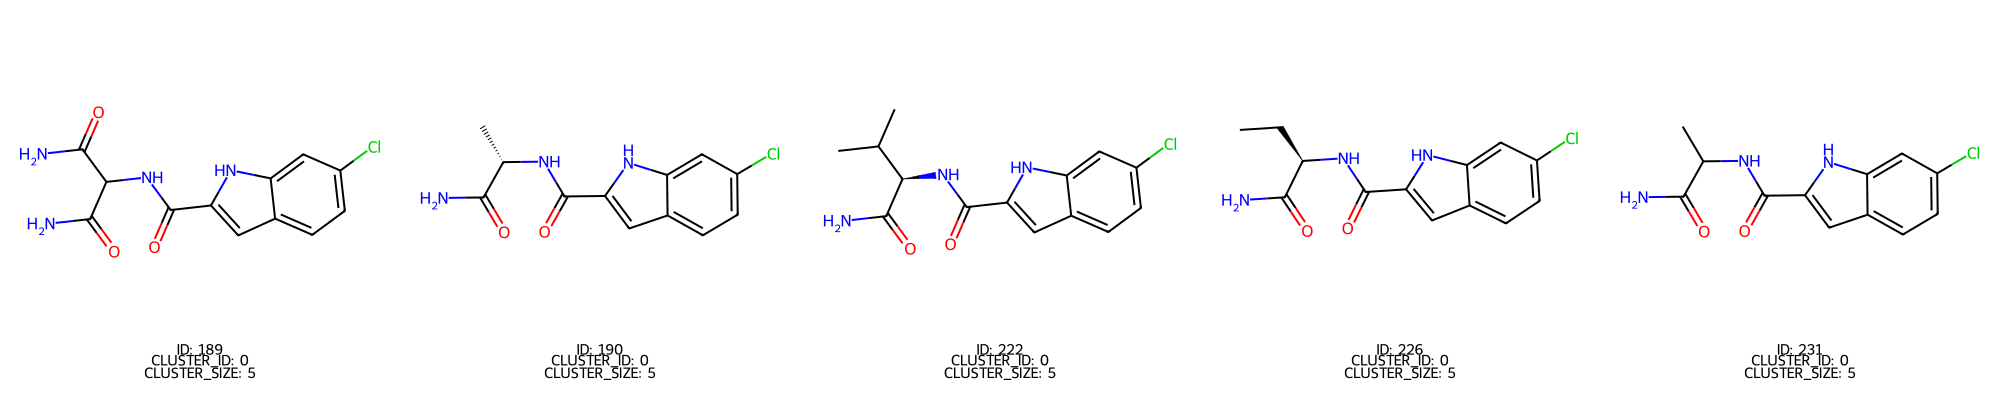

In [ ]:
# Cluster analysis for each dataset
clustered_inputs = {}

for (model_name, dataset_name), enabled in RUN_TASKS.items():
    if not enabled:
        continue
        
    # Skip if we already processed this dataset
    if dataset_name in clustered_inputs:
        continue
    
    try:
        # Load dataset
        dataset_config = DATASETS[dataset_name]
        df = pd.read_csv(dataset_config['test_file'])
        
        # Apply subset if configured
        max_samples = dataset_config.get('max_samples', None)
        if max_samples is not None and max_samples > 0:
            df = df.sample(n=max_samples, random_state=42)
        
        smiles_list = df[dataset_config['smiles_column']].tolist()
        
        print(f"\n{'='*60}")
        print(f"Clustering Analysis: {DATASETS[dataset_name]['name']}")
        print(f"{'='*60}\n")
        
        # Perform clustering
        clusters = cluster_molecules(smiles_list, cutoff=0.35, fp_type="morgan2")
        clusters_df = interpret_clusters(clusters)
        
        # Merge with original data
        display(df)
        display(clusters_df)
        input_df_wclus = pd.concat([df, clusters_df], axis=1)
        
        print(f"Total molecules: {len(df)}")
        print(f"Number of clusters: {len(clusters)}")
        print(f"Largest cluster size: {clusters_df['CLUSTER_SIZE'].max()}")
        print(f"Average cluster size: {clusters_df['CLUSTER_SIZE'].mean():.2f}")
        
        # Display sample of clustered data
        print("\nSample of clustered data:")
        display(input_df_wclus.head(10))
        
        # Visualize largest cluster
        print(f"\nVisualizing largest cluster (Cluster ID: 0):")
        df_to_draw = input_df_wclus[input_df_wclus["CLUSTER_ID"] == 0]
        imglist = plotmolblocks_n(
            df_to_draw[dataset_config['smiles_column']], 
            labels=df_to_draw[["ID", "CLUSTER_ID", "CLUSTER_SIZE"]]
        )
        display(imglist[0])
        
        # Store clustered data for later use
        clustered_inputs[dataset_name] = {
            'df': input_df_wclus,
            'clusters_df': clusters_df
        }
        
    except Exception as e:
        print(f"\n❌ Error clustering {dataset_name}: {str(e)}\n")
        import traceback
        traceback.print_exc()

---
## Step 6: Collect Model Predictions


In [ ]:
# Storage for all results
all_results = []
all_metrics = []

# Iterate through all enabled tasks
for (model_name, dataset_name), enabled in RUN_TASKS.items():
    if not enabled:
        print(f"Skipping {model_name} on {dataset_name}")
        continue
    print(model_name, dataset_name)
    # Load dataset
    dataset_config = DATASETS[dataset_name]
    df = pd.read_csv(dataset_config['test_file'])
    df["sample_id"] = df.index  # Add sample ID for tracking
    display(df)

    smiles_list = df[dataset_config['smiles_column']].tolist()
    y_true = df[dataset_config['label_column']].tolist()

    pred_file = dataset_config['pred_file_pattern'].format(model=model_name)
    print(f"*****{pred_file=}*****")
    df_predictions = pd.read_csv(pred_file)
    display(df_predictions)

    y_pred_proba = df_predictions['prediction_score'].tolist()
    # Calculate metrics
    metrics = calculate_metrics(
        y_true=y_true,
        y_pred_proba=y_pred_proba,
        model_name=model_name,
        dataset_name=DATASETS[dataset_name]['name']
    )
    
    # Print metrics
    print_metrics(metrics)
        
    # Store results
    all_metrics.append(metrics)
    all_results.append({
        'model': model_name,
        'dataset': dataset_name,
        'predictions': df_predictions,
        'metrics': metrics
    })
        


Skipping mmelon on pgk2
mmelon wdr91


,smiles,label,sample_id
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4
...,...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0,229
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0,230
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0,231
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0,232


*****pred_file='/proj/ligand_ai/users/ozery/results/wdr91_mmelon_predictions.csv'*****


,predicted_label,prediction_score
0,0,3.548e-03
1,0,8.050e-04
2,0,5.423e-03
3,0,1.409e-03
4,0,1.015e-02
...,...,...
229,0,3.363e-03
230,0,2.402e-03
231,0,4.327e-04
232,0,8.512e-04



Metrics: mmelon on WDR91 ASMS
Samples:    234
ROC-AUC:    0.7907
PR-AUC:     0.5733
Accuracy:   0.7521
Precision:  0.0000
Recall:     0.0000
F1-Score:   0.0000

Skipping mammal on pgk2
mammal wdr91


,smiles,label,sample_id
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4
...,...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0,229
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0,230
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0,231
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0,232


*****pred_file='/proj/ligand_ai/users/ozery/results/wdr91_mammal_predictions.csv'*****


,sample_id,predicted_label,prediction_score
0,0,0,1.982e-01
1,1,1,8.563e-01
2,2,0,1.942e-02
3,3,0,1.542e-01
4,4,0,6.396e-04
...,...,...,...
229,229,0,1.475e-06
230,230,0,5.014e-05
231,231,0,3.810e-06
232,232,0,1.329e-06



Metrics: mammal on WDR91 ASMS
Samples:    234
ROC-AUC:    0.8892
PR-AUC:     0.7496
Accuracy:   0.7906
Precision:  0.8462
Recall:     0.1897
F1-Score:   0.3099



---
## Step 7: Results Summary

Display comprehensive comparison of all models and datasets.

In [ ]:
pd.set_option("display.precision", 3)
# Create summary DataFrame grouped by dataset
from collections import defaultdict

if all_metrics:
    df_summary = pd.DataFrame(all_metrics)
    
    # Group metrics by dataset
    metrics_by_dataset = defaultdict(list)
    for metric in all_metrics:
        dataset = metric['dataset']
        metrics_by_dataset[dataset].append(metric)
    
    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY - GROUPED BY DATASET")
    print("="*80)
    
    # Display results for each dataset
    for dataset_name, dataset_metrics in metrics_by_dataset.items():
        print(f"\n{'─'*80}")
        print(f"DATASET: {dataset_name}")
        print(f"{'─'*80}\n")
        
        # Create DataFrame for this dataset
        df_dataset = pd.DataFrame(dataset_metrics)
        display(df_dataset)

    # Save summary to CSV
    output_file = 'model_comparison_summary.csv'
    df_summary.to_csv(f"{RESULTS_DIR}/{output_file}", index=False)
    print(f"\n✅ Summary saved to: {output_file}")  
    

    print("\n" + "="*80)
    print("OVERALL COMPARISON")
    print("="*80 + "\n")
    
    # Pivot table for ROC-AUC
    pivot_roc = df_summary.pivot(index='dataset', columns='model', values='roc_auc')
    
    # Pivot table for PR-AUC
    pivot_pr = df_summary.pivot(index='dataset', columns='model', values='pr_auc')


    df_all = pd.concat([pivot_roc, pivot_pr], axis=1, keys=["ROC-AUC", "PR-AUC"])

    # df_all.columns.names = ["metric", "model"]  # optional: name the levels for clarity
    display(df_all)
   
else:
    print("\n⚠️ No results to display. Check if any tasks were enabled and ran successfully.")


FINAL RESULTS SUMMARY - GROUPED BY DATASET

────────────────────────────────────────────────────────────────────────────────
DATASET: WDR91 ASMS
────────────────────────────────────────────────────────────────────────────────



,model,dataset,n_samples,roc_auc,pr_auc,accuracy,precision,recall,f1_score
0,mmelon,WDR91 ASMS,234,0.791,0.573,0.752,0.000,0.00,0.00
1,mammal,WDR91 ASMS,234,0.889,0.750,0.791,0.846,0.19,0.31



✅ Summary saved to: model_comparison_summary.csv

OVERALL COMPARISON



ROC-AUC        PR-AUC       
model       mammal mmelon mammal mmelon
dataset                                
WDR91 ASMS   0.889  0.791   0.75  0.573

## Step 8: Enrichment Metrics Analysis

Calculate Precision@K and Enrichment Factor (EF@K) for each model-dataset combination.

**EF@K** = Precision@K / hit_prevalence  
where hit_prevalence = fraction of positives in the full dataset.

In [ ]:
# Calculate enrichment metrics grouped by dataset for easy comparison
from collections import defaultdict

# Group results by dataset
results_by_dataset = defaultdict(list)
for result in all_results:
    dataset = result['dataset']
    results_by_dataset[dataset].append(result)

# Process each dataset
results_dict = {}
for dataset_name, dataset_results in results_by_dataset.items():
    print(f"\n{'='*80}")
    print(f"DATASET: {DATASETS[dataset_name]['name']}")
    print(f"{'='*80}")
    
    # Load dataset once for this group
    dataset_config = DATASETS[dataset_name]
    df = pd.read_csv(dataset_config['test_file'])
    
    y_true = df[dataset_config['label_column']].values
    results_dict[dataset_name] = {}
    # Calculate enrichment for each model on this dataset
    for result in dataset_results:
        model = result['model']
        predictions_df = result['predictions']
        
        y_scores = predictions_df['prediction_score'].values
        
        # Calculate and print enrichment metrics
        ef_df = print_enrichment_metrics(
            y_true=y_true,
            y_scores=y_scores,
            dataset_name=f"{model}"
        )
        results_dict[dataset_name][model] = ef_df
        
        print("\nEnrichment DataFrame:")
        display(ef_df)
        print("\n")
            

    print(f"{'='*80}")
    print(f"END OF {DATASETS[dataset_name]['name']} COMPARISON")
    print(f"{'='*80}\n")


DATASET: WDR91 ASMS
ENRICHMENT METRICS - mmelon
Dataset: 234 compounds  |  Positives: 58  |  Hit rate: 24.79%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        0.7000      2.82               7
      50        0.6000      2.42              30
     100        0.4100      1.65              41
     200        0.2850      1.15              57
     234        0.2479      1.00              58

Enrichment DataFrame:


,K,Precision@K,EF@K,Hits_in_top_K
0,10,0.700,2.824,7
1,50,0.600,2.421,30
2,100,0.410,1.654,41
3,200,0.285,1.150,57
4,234,0.248,1.000,58




ENRICHMENT METRICS - mammal
Dataset: 234 compounds  |  Positives: 58  |  Hit rate: 24.79%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        0.9000      3.63               9
      50        0.7800      3.15              39
     100        0.5100      2.06              51
     200        0.2850      1.15              57
     234        0.2479      1.00              58

Enrichment DataFrame:


,K,Precision@K,EF@K,Hits_in_top_K
0,10,0.900,3.631,9
1,50,0.780,3.147,39
2,100,0.510,2.058,51
3,200,0.285,1.150,57
4,234,0.248,1.000,58




END OF WDR91 ASMS COMPARISON



In [ ]:
import pandas as pd

def build_panel_metric_at_k(results_dict, selected_k, metrics=None, sep='@'):
    """
    Build a wide DataFrame where:
      - Index: dataset
      - Columns: MultiIndex (metric@k, model)
      - Values: metric value at the given K

    Parameters
    ----------
    results_dict : dict
        Nested dict: results_dict[dataset][model] -> DataFrame
        Each df must contain 'K' column or have K as index, plus metric columns.
    selected_k : list
        K values to include, e.g. [10, 50, 100].
    metrics : list or None
        Metric columns to include; if None, inferred from df (all except 'K').
    sep : str
        Separator used between metric name and k in level-0 columns, default '@'.

    Returns
    -------
    wide : pd.DataFrame
        Columns: MultiIndex(levels=[metric@k, model])
    """
    records = []

    for dataset, models in results_dict.items():
        for model, df in models.items():
            t = df.copy()
            # Ensure K is the index
            if 'K' in t.columns:
                t = t.set_index('K')
            t.index.name = 'K'

            metric_cols = ([c for c in t.columns if c != 'K']
                           if metrics is None
                           else [m for m in metrics if m in t.columns])

            ks_present = [k for k in selected_k if k in t.index]

            # collect long rows
            for m in metric_cols:
                for k in ks_present:
                    records.append({
                        'dataset': dataset,
                        'metric_at_k': f"{m}{sep}{k}",
                        'model': model,
                        'value': t.loc[k, m]
                    })

    long = pd.DataFrame.from_records(records)

    # pivot to (metric@k, model)
    wide = (long
            .pivot_table(index='dataset',
                         columns=['metric_at_k', 'model'],
                         values='value',
                         aggfunc='first'))

    return wide

# --- example usage ---
selected_k = [10, 50, 100, 200]
metrics = ['Precision@K', 'EF@K', 'Hits in top-K']  # or None to infer
panel = build_panel_metric_at_k(results_dict, selected_k, metrics=metrics)
display(panel)


metric_at_k EF@K@10        EF@K@100        EF@K@200        EF@K@50         \
model        mammal mmelon   mammal mmelon   mammal mmelon  mammal mmelon   
dataset                                                                     
wdr91         3.631  2.824    2.058  1.654     1.15   1.15   3.147  2.421   

metric_at_k Precision@K@10        Precision@K@100        Precision@K@200  \
model               mammal mmelon          mammal mmelon          mammal   
dataset                                                                    
wdr91                  0.9    0.7            0.51   0.41           0.285   

metric_at_k        Precision@K@50         
model       mmelon         mammal mmelon  
dataset                                   
wdr91        0.285           0.78    0.6

## Step 9: Visualize Top Predictions with Cluster Information

Visualize the top predicted hits with their cluster assignments to identify diverse candidates.

In [ ]:
for kk, vv in clustered_inputs.items():
    print(kk, "******")
    print(kk, vv["df"].shape, vv["clusters_df"].shape)
    display(vv["df"])
    display(vv["clusters_df"])

wdr91 ******
wdr91 (234, 6) (234, 4)


,smiles,label,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,209,1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1,1,5,0
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2,208,1,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3,1,5,0
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4,207,1,1
...,...,...,...,...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0,229,18,1,1
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0,230,17,1,1
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0,231,0,5,1
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0,232,16,1,1


,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,0,209,1,1
1,1,1,5,0
2,2,208,1,1
3,3,1,5,0
4,4,207,1,1
...,...,...,...,...
229,229,18,1,1
230,230,17,1,1
231,231,0,5,1
232,232,16,1,1


In [ ]:
clustered_inputs.keys()

dict_keys(['wdr91'])


DATASET: WDR91 ASMS - Top Predictions Visualization

***** input_df_indexed.shape=(234, 2) input_df_indexed.columns=Index(['smiles', 'label'], dtype='object')


,smiles,label
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1
...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0


***** predictions_df_indexed.shape=(234, 2) predictions_df_indexed.columns=Index(['predicted_label', 'prediction_score'], dtype='object')


,predicted_label,prediction_score
0,0,3.548e-03
1,0,8.050e-04
2,0,5.423e-03
3,0,1.409e-03
4,0,1.015e-02
...,...,...
229,0,3.363e-03
230,0,2.402e-03
231,0,4.327e-04
232,0,8.512e-04


***** clusters_df_indexed.shape=(234, 6)clusters_df_indexed.columns=Index(['smiles', 'label', 'ID', 'CLUSTER_ID', 'CLUSTER_SIZE',
       'CLUSTER_CENTROID'],
      dtype='object')


,smiles,label,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,209,1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1,1,5,0
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2,208,1,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3,1,5,0
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4,207,1,1
...,...,...,...,...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0,229,18,1,1
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0,230,17,1,1
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0,231,0,5,1
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0,232,16,1,1



────────────────────────────────────────────────────────────
Model: mmelon
────────────────────────────────────────────────────────────

Top 10 molecules by prediction_score:


,smiles,prediction_score,CLUSTER_ID,CLUSTER_SIZE
0,O=C(O)c1ccc(-n2c(C=Cc3cccc4nccn34)nc3ccccc3c2=...,0.015,56,1
1,CN(C)c1ccc(C(=O)NC(c2ccccc2)c2ccccn2)cc1F,0.012,167,1
2,CS(=O)(=O)c1cccc(C(NC(=O)c2ccc(C(=O)O)cc2)c2cc...,0.011,197,1
3,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,0.010,207,1
4,NC(=O)c1ccc(C(=O)NC(c2ccc(F)cc2)c2cccs2)nc1,0.010,180,1
5,Cc1cc(C)c2cc(C(=O)NC(c3ccc4ccccc4c3)c3nn[nH]n3...,0.009,159,1
6,O=C(NC(c1ccccc1)c1ccoc1)c1c[nH]n2c1nc(=O)c1ccc...,0.008,144,1
7,Cn1ccnc1C(NC(=O)c1ccc2c(c1)C(N)CCC2)c1ccc(Cl)cc1,0.008,204,1
8,CC(=O)N1CCc2cc(C(=O)NC(c3ccc(Cl)cc3)c3nccn3C)c...,0.007,11,2
9,Cn1ccnc1C(NC(=O)c1ccc2c(c1)NC(=O)CO2)c1ccc(Cl)cc1,0.006,184,1



Visualization of top 10 predictions:


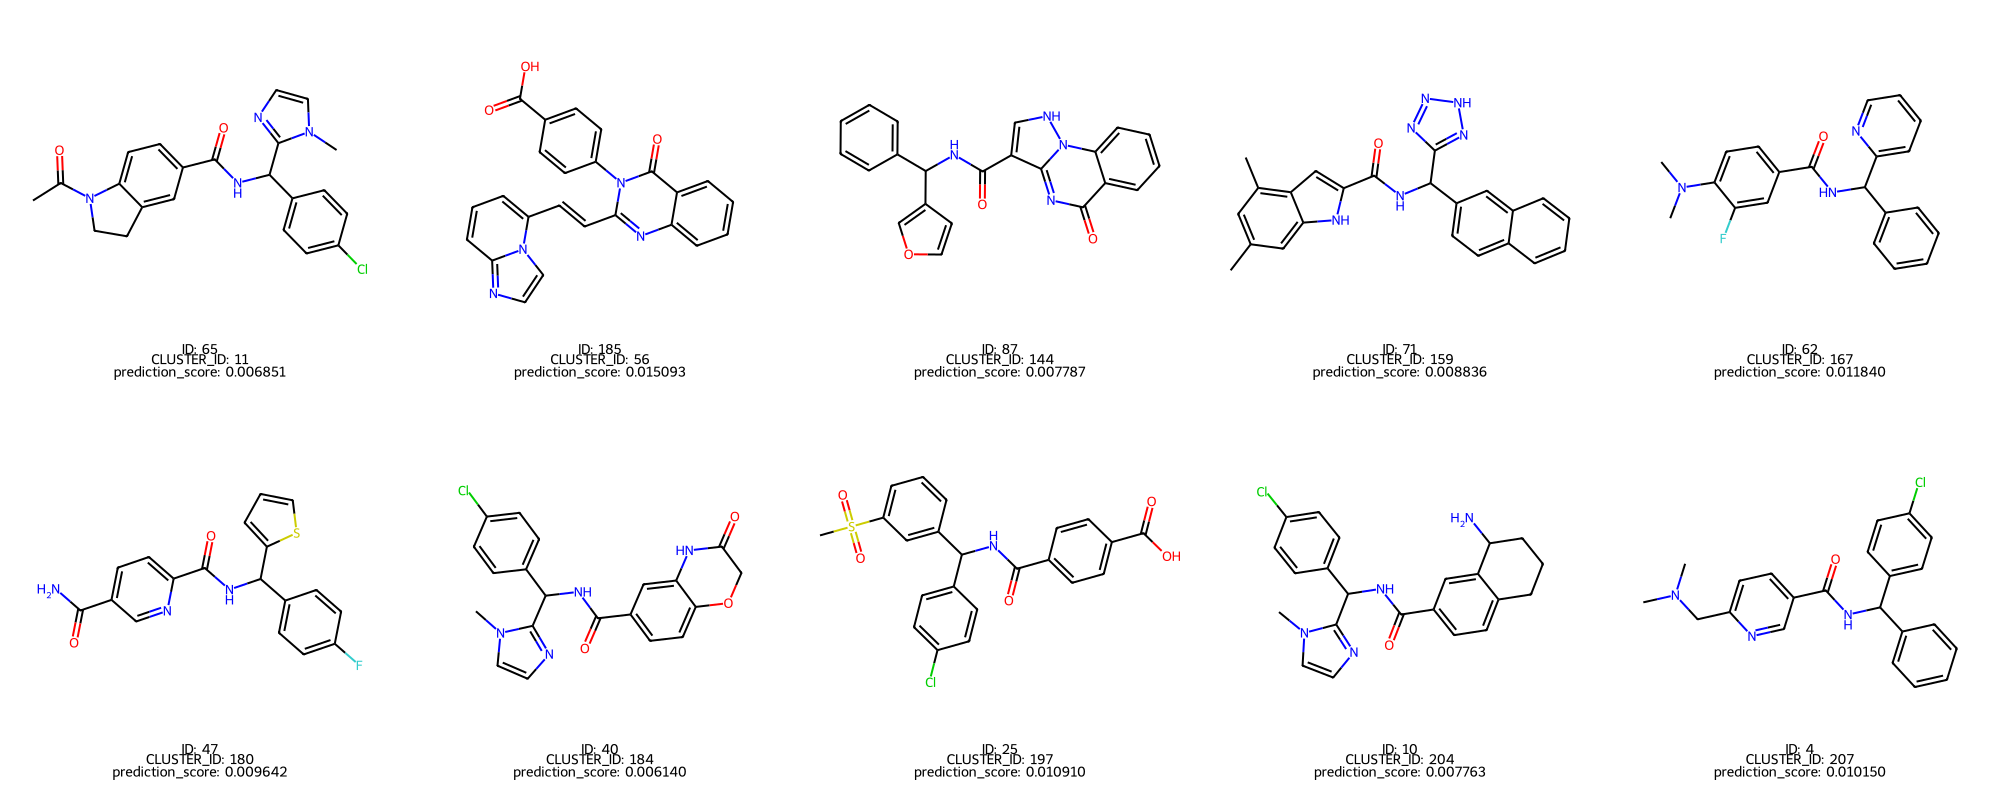


Cluster diversity in top 20:
  - Unique clusters: 10
  - Cluster distribution:
CLUSTER_ID
56     1
167    1
197    1
207    1
180    1
159    1
144    1
204    1
11     1
184    1
Name: count, dtype: int64

***** input_df_indexed.shape=(234, 2) input_df_indexed.columns=Index(['smiles', 'label'], dtype='object')


,smiles,label
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1
...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0


***** predictions_df_indexed.shape=(234, 3) predictions_df_indexed.columns=Index(['sample_id', 'predicted_label', 'prediction_score'], dtype='object')


,sample_id,predicted_label,prediction_score
0,0,0,1.982e-01
1,1,1,8.563e-01
2,2,0,1.942e-02
3,3,0,1.542e-01
4,4,0,6.396e-04
...,...,...,...
229,229,0,1.475e-06
230,230,0,5.014e-05
231,231,0,3.810e-06
232,232,0,1.329e-06


***** clusters_df_indexed.shape=(234, 6)clusters_df_indexed.columns=Index(['smiles', 'label', 'ID', 'CLUSTER_ID', 'CLUSTER_SIZE',
       'CLUSTER_CENTROID'],
      dtype='object')


,smiles,label,ID,CLUSTER_ID,CLUSTER_SIZE,CLUSTER_CENTROID
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,209,1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,1,1,5,0
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,2,208,1,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,3,1,5,0
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,4,207,1,1
...,...,...,...,...,...,...
229,CC(NC(=O)c1cnc2cnccc2c1)c1ccc2c(c1)NC(=O)CO2,0,229,18,1,1
230,NS(=O)(=O)c1cccc(CNC(=O)c2cccc3ncccc23)c1,0,230,17,1,1
231,CC(NC(=O)c1cc2ccc(Cl)cc2[nH]1)C(N)=O,0,231,0,5,1
232,O=C(NCc1cccc(-n2cc(C(O)c3ccc(F)cc3)nn2)c1)c1cc...,0,232,16,1,1



────────────────────────────────────────────────────────────
Model: mammal
────────────────────────────────────────────────────────────

Top 10 molecules by prediction_score:


,smiles,prediction_score,CLUSTER_ID,CLUSTER_SIZE
0,CCn1c(=O)[nH]c2cc(C(=O)NC(c3ccc(F)cc3)c3cnn(C)...,0.934,187,1
1,CC(C)(C)OC(=O)N1CCn2nc(C(=O)NCc3ccc(Cl)c4cccnc...,0.920,59,1
2,COC(=O)CC(NC(=O)c1cc2c(C)nn(C)c2s1)c1ccc(Cl)cc1,0.909,185,1
3,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,0.871,205,1
4,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,0.856,1,5
5,Cn1ccnc1C(NC(=O)c1ccc2c(c1)CCCN2S(C)(=O)=O)c1c...,0.793,11,2
6,Cn1ccnc1C(NC(=O)c1ccc2c(c1)NC(=O)CO2)c1ccc(Cl)cc1,0.747,184,1
7,O=C(O)CC(NC(=O)c1ccc(CN2CCCC2=O)cc1)c1ccc(Cl)cc1,0.735,196,1
8,C[C@@H](NC(=O)c1ccc2c(c1)NC(=O)CO2)c1cccc(Cl)c1,0.700,12,2
9,COC(=O)CC(NC(=O)c1ccc2c(c1)OCC(=O)N2)c1ccc(Cl)cc1,0.653,188,1



Visualization of top 10 predictions:


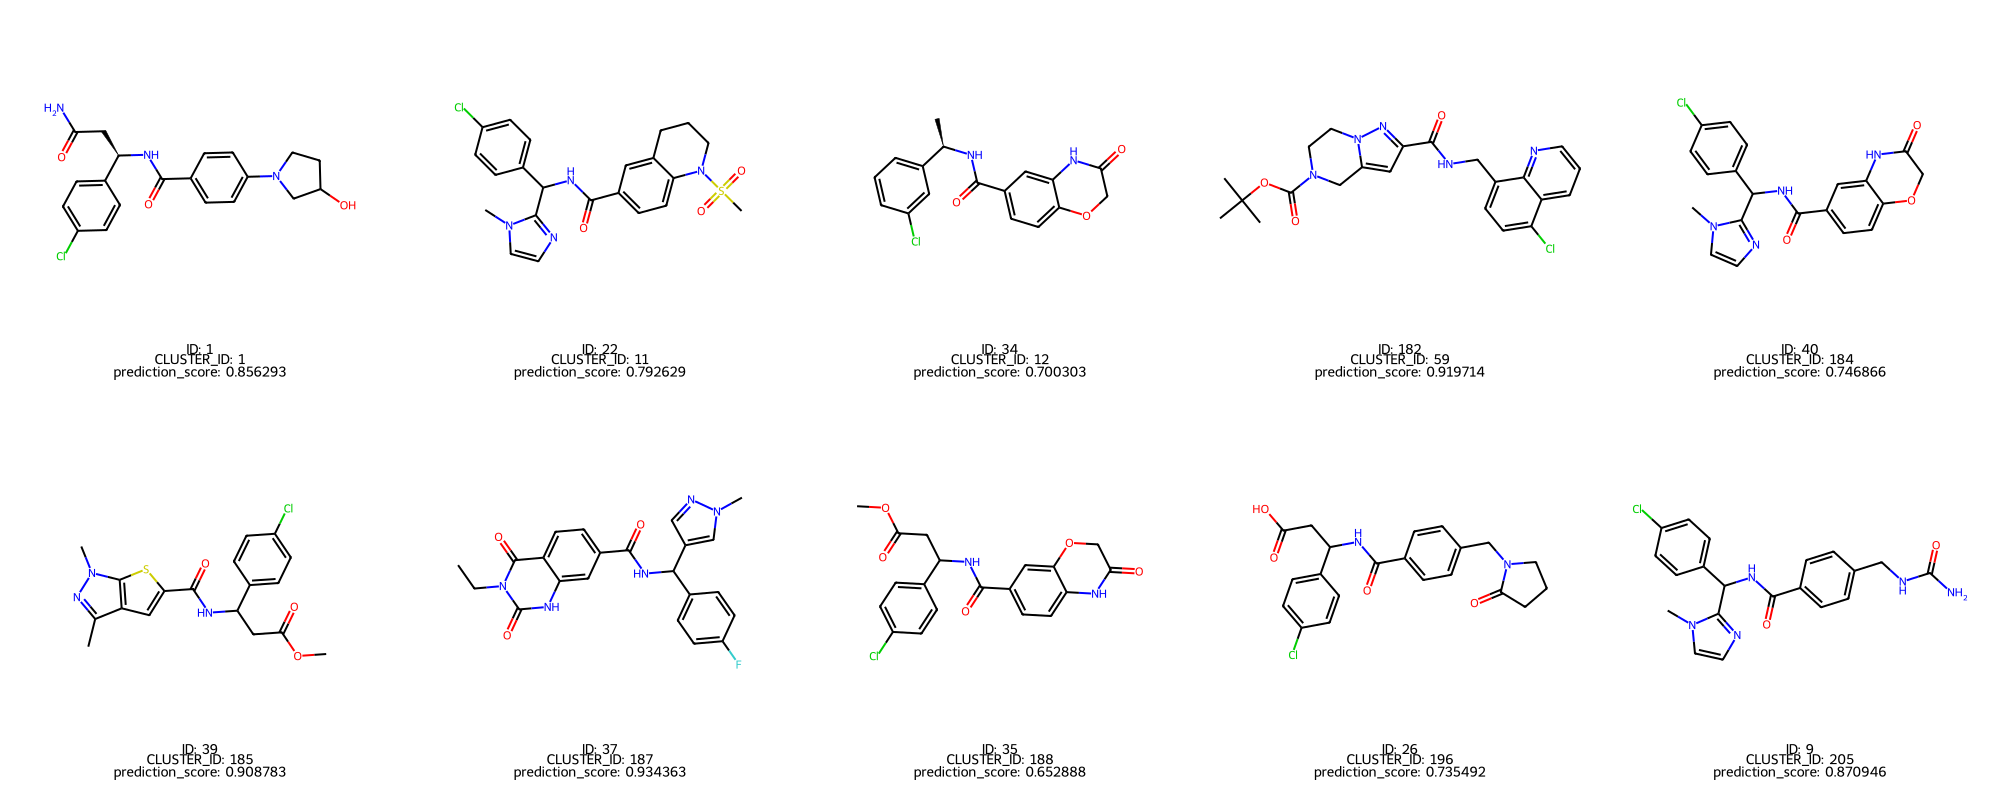


Cluster diversity in top 20:
  - Unique clusters: 10
  - Cluster distribution:
CLUSTER_ID
187    1
59     1
185    1
205    1
1      1
11     1
184    1
196    1
12     1
188    1
Name: count, dtype: int64


END OF WDR91 ASMS VISUALIZATION



In [ ]:
# Visualize top predictions grouped by dataset for easy comparison
from collections import defaultdict

# Group results by dataset
results_by_dataset = defaultdict(list)
for result in all_results:
    dataset = result['dataset']
    results_by_dataset[dataset].append(result)

K=10
# Process each dataset
for dataset_name, dataset_results in results_by_dataset.items():
    print(f"\n{'='*80}")
    print(f"DATASET: {DATASETS[dataset_name]['name']} - Top Predictions Visualization")
    print(f"{'='*80}\n")

    
    # Get cluster information if available
    if dataset_name in clustered_inputs:
    
        clusters_df = clustered_inputs[dataset_name]['df']
        dataset_config = DATASETS[dataset_name]
        input_df = pd.read_csv(dataset_config['test_file'])
        
        # Visualize for each model on this dataset
        for result in dataset_results:
            model = result['model']
            predictions_df = result['predictions']
            
            # Merge predictions with cluster information
            # First, ensure all dataframes have proper indices
            input_df_indexed = input_df.reset_index(drop=True)
            predictions_df_indexed = predictions_df.reset_index(drop=True)
            clusters_df_indexed = clusters_df
            
               
            print(f"***** {input_df_indexed.shape=} {input_df_indexed.columns=}")
            display(input_df_indexed)
            print(f"***** {predictions_df_indexed.shape=} {predictions_df_indexed.columns=}")
            display(predictions_df_indexed)
            print(f"***** {clusters_df_indexed.shape=}{clusters_df_indexed.columns=}")
            display(clusters_df_indexed)
            df_all = pd.concat([input_df_indexed, predictions_df_indexed], axis=1).merge(clusters_df_indexed, on=["smiles", "label"])
            assert df_all.shape[0] == clusters_df_indexed.shape[0]

            print(f"\n{'─'*60}")
            print(f"Model: {model}")
            print(f"{'─'*60}\n")
            
            # Get score column name based on model
            score_col = 'prediction_score'
            
            # Sort by prediction score and get top 20
            topK = df_all.sort_values(score_col, ascending=False).head(K).reset_index(drop=True)
            
            print(f"Top {K} molecules by {score_col}:")
            display(topK[['smiles', score_col, 'CLUSTER_ID', 'CLUSTER_SIZE']].head(20))
                            
            topK_sorted = topK.sort_values(by="CLUSTER_ID")            
            # Visualize top 20 molecules
            print(f"\nVisualization of top {K} predictions:")
            imglist = plotmolblocks_n(
                topK_sorted[dataset_config['smiles_column']], 
                labels=topK_sorted[["ID", "CLUSTER_ID", score_col]]
            )
            display(imglist[0])
            
            # Cluster diversity analysis
            unique_clusters = topK['CLUSTER_ID'].nunique()
            print(f"\nCluster diversity in top 20:")
            print(f"  - Unique clusters: {unique_clusters}")
            print(f"  - Cluster distribution:")
            print(topK['CLUSTER_ID'].value_counts().head(10))
            print()
                
            
    else:
        print(f"⚠️  No clustering data available for {dataset_name}")
    
    print(f"\n{'='*80}")
    print(f"END OF {DATASETS[dataset_name]['name']} VISUALIZATION")
    print(f"{'='*80}\n")

---
## Notes

### Customization:

- Modify `DATASETS` dictionary to add new datasets or change file paths
- Adjust `RUN_TASKS` to enable/disable specific model-dataset combinations


### Output Files:

- `model_comparison_summary.csv`: Overall metrics comparison
- `predictions_{model}_{dataset}.csv`: Detailed predictions for each combination
